In [1]:
import pandas as pd

In [4]:
df = pd.read_pickle("complete_dataset_labeled.pkl")
df_cpu = df[df['Interference_Category'] == 'CPU'].copy()
df_baseline = df[df['Interference_Category'] == 'Baseline'].copy()

unique_rps = df_cpu['Given_RPS'].unique()
unique_replicas = df_cpu['Replicas'].unique()

isolation_rows = []
for rps in unique_rps:
    for rep in unique_replicas:
        isolation_rows.append({
            'Scenario_Label': 'Isolation',
            'Given_RPS': rps,
            'Replicas': rep,
            'norm_perf': 1.0,
            'Interference_Category': 'CPU'
        })

df_isolation = pd.DataFrame(isolation_rows)

# 3. Combine
df_cpu_isolation = pd.concat([df_cpu, df_isolation], ignore_index=True)


In [13]:
display(df)

,UniqueID,Test_ID,Replicas,Interference_Name,Interference_ID,Given_RPS,FolderID,Throughput,Avg_Latency,P50_Latency,P75_Latency,P90_Latency,P95_Latency,P99_Latency,Max_Latency,Errors,Interference_Category,norm_perf,Scenario_Label
0,1replicas_scenario0_1000rps_Fight_Club_V01,1replicas_scenario0_1000rps,1,Baseline0,0,1000,Fight_Club_V01,1000.004331,0.087,0.084,0.0,0.100,0.108,0.141,2.682,0.0,Baseline,1.000000,B0
1,1replicas_scenario0_1000rps_Memento_V01,1replicas_scenario0_1000rps,1,Baseline0,0,1000,Memento_V01,1000.002275,0.087,0.084,0.0,0.100,0.108,0.150,3.678,0.0,Baseline,1.000000,B0
2,1replicas_scenario0_1000rps_TheGame_V01,1replicas_scenario0_1000rps,1,Baseline0,0,1000,TheGame_V01,1000.003594,0.088,0.085,0.0,0.102,0.111,0.146,3.211,0.0,Baseline,1.000000,B0
3,1replicas_scenario0_100rps_Memento_V01,1replicas_scenario0_100rps,1,Baseline0,0,100,Memento_V01,100.004986,0.301,0.312,0.0,0.480,0.541,0.598,1.005,0.0,Baseline,1.000000,B0
4,1replicas_scenario0_100rps_TheGame_V01,1replicas_scenario0_100rps,1,Baseline0,0,100,TheGame_V01,100.005097,0.295,0.310,0.0,0.442,0.539,0.606,2.918,0.0,Baseline,1.000000,B0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1904,4replicas_scenario58_2500rps_TheGame_MIX_V02,4replicas_scenario58_2500rps,4,1_L3_3_MemBW,58,2500,TheGame_MIX_V02,2500.004305,0.217,0.165,0.0,0.413,0.522,0.723,5.128,0.0,Mix,0.261872,MIX8
1905,4replicas_scenario58_3000rps_TheGame_MIX_V02,4replicas_scenario58_3000rps,4,1_L3_3_MemBW,58,3000,TheGame_MIX_V02,3000.000833,0.278,0.247,0.0,0.430,0.506,0.776,10.012,0.0,Mix,0.262887,MIX8
1906,4replicas_scenario58_3500rps_TheGame_MIX_V02,4replicas_scenario58_3500rps,4,1_L3_3_MemBW,58,3500,TheGame_MIX_V02,3500.001452,0.201,0.162,0.0,0.356,0.427,0.635,7.087,0.0,Mix,0.381890,MIX8
1907,4replicas_scenario58_4000rps_TheGame_MIX_V02,4replicas_scenario58_4000rps,4,1_L3_3_MemBW,58,4000,TheGame_MIX_V02,4000.018785,0.232,0.190,0.0,0.388,0.486,0.877,11.036,0.0,Mix,0.333903,MIX8


In [14]:
display(df_cpu)

,UniqueID,Test_ID,Replicas,Interference_Name,Interference_ID,Given_RPS,FolderID,Throughput,Avg_Latency,P50_Latency,P75_Latency,P90_Latency,P95_Latency,P99_Latency,Max_Latency,Errors,Interference_Category,norm_perf,Scenario_Label
26,1replicas_scenario11_1000rps_Fight_Club_V01,1replicas_scenario11_1000rps,1,1_iBench_CPU_pod,11,1000,Fight_Club_V01,999.999817,0.095,0.084,0.0,0.102,0.111,0.188,3.957,0.0,CPU,0.766548,CPU1
27,1replicas_scenario11_1000rps_Memento_V01,1replicas_scenario11_1000rps,1,1_iBench_CPU_pod,11,1000,Memento_V01,1000.004199,0.098,0.085,0.0,0.102,0.112,0.187,4.857,0.0,CPU,0.770648,CPU1
28,1replicas_scenario11_1000rps_TheGame_V01,1replicas_scenario11_1000rps,1,1_iBench_CPU_pod,11,1000,TheGame_V01,1000.002916,0.089,0.086,0.0,0.103,0.111,0.145,3.252,0.0,CPU,0.993870,CPU1
29,1replicas_scenario11_100rps_Memento_V01,1replicas_scenario11_100rps,1,1_iBench_CPU_pod,11,100,Memento_V01,100.005151,0.337,0.314,0.0,0.501,0.562,1.756,3.351,0.0,CPU,0.342635,CPU1
30,1replicas_scenario11_100rps_TheGame_V01,1replicas_scenario11_100rps,1,1_iBench_CPU_pod,11,100,TheGame_V01,100.005318,0.290,0.301,0.0,0.415,0.522,0.594,2.238,0.0,CPU,1.012907,CPU1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1652,4replicas_scenario14_3500rps_TheGame_V04,4replicas_scenario14_3500rps,4,4_iBench_CPU_pods,14,3500,TheGame_V04,3500.003480,0.247,0.224,0.0,0.334,0.387,0.665,5.934,0.0,CPU,0.364662,CPU4
1653,4replicas_scenario14_4000rps_Memento_V04,4replicas_scenario14_4000rps,4,4_iBench_CPU_pods,14,4000,Memento_V04,4000.013516,0.240,0.161,0.0,0.385,0.616,1.975,7.172,0.0,CPU,0.148270,CPU4
1654,4replicas_scenario14_4000rps_TheGame_V04,4replicas_scenario14_4000rps,4,4_iBench_CPU_pods,14,4000,TheGame_V04,4000.000582,0.186,0.162,0.0,0.316,0.374,0.621,4.974,0.0,CPU,0.471551,CPU4
1655,4replicas_scenario14_500rps_Memento_V04,4replicas_scenario14_500rps,4,4_iBench_CPU_pods,14,500,Memento_V04,500.002651,0.174,0.093,0.0,0.160,0.235,2.506,6.693,0.0,CPU,0.069699,CPU4


In [12]:
display(df_baseline)

,UniqueID,Test_ID,Replicas,Interference_Name,Interference_ID,Given_RPS,FolderID,Throughput,Avg_Latency,P50_Latency,P75_Latency,P90_Latency,P95_Latency,P99_Latency,Max_Latency,Errors,Interference_Category,norm_perf,Scenario_Label
0,1replicas_scenario0_1000rps_Fight_Club_V01,1replicas_scenario0_1000rps,1,Baseline0,0,1000,Fight_Club_V01,1000.004331,0.087,0.084,0.0,0.100,0.108,0.141,2.682,0.0,Baseline,1.0,B0
1,1replicas_scenario0_1000rps_Memento_V01,1replicas_scenario0_1000rps,1,Baseline0,0,1000,Memento_V01,1000.002275,0.087,0.084,0.0,0.100,0.108,0.150,3.678,0.0,Baseline,1.0,B0
2,1replicas_scenario0_1000rps_TheGame_V01,1replicas_scenario0_1000rps,1,Baseline0,0,1000,TheGame_V01,1000.003594,0.088,0.085,0.0,0.102,0.111,0.146,3.211,0.0,Baseline,1.0,B0
3,1replicas_scenario0_100rps_Memento_V01,1replicas_scenario0_100rps,1,Baseline0,0,100,Memento_V01,100.004986,0.301,0.312,0.0,0.480,0.541,0.598,1.005,0.0,Baseline,1.0,B0
4,1replicas_scenario0_100rps_TheGame_V01,1replicas_scenario0_100rps,1,Baseline0,0,100,TheGame_V01,100.005097,0.295,0.310,0.0,0.442,0.539,0.606,2.918,0.0,Baseline,1.0,B0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760,4replicas_scenario2_3500rps_TheGame_V04,4replicas_scenario2_3500rps,4,Baseline2,2,3500,TheGame_V04,3500.006029,0.105,0.095,0.0,0.137,0.159,0.270,3.806,0.0,Baseline,1.0,B2
1761,4replicas_scenario2_4000rps_Memento_V04,4replicas_scenario2_4000rps,4,Baseline2,2,4000,Memento_V04,4000.004136,0.096,0.088,0.0,0.127,0.144,0.212,3.523,0.0,Baseline,1.0,B2
1762,4replicas_scenario2_4000rps_TheGame_V04,4replicas_scenario2_4000rps,4,Baseline2,2,4000,TheGame_V04,4000.005139,0.121,0.102,0.0,0.177,0.228,0.396,4.334,0.0,Baseline,1.0,B2
1763,4replicas_scenario2_500rps_Memento_V04,4replicas_scenario2_500rps,4,Baseline2,2,500,Memento_V04,500.002919,0.088,0.084,0.0,0.102,0.111,0.159,2.334,0.0,Baseline,1.0,B2


In [16]:
# 1. Define the columns we want to group by and the metric to average
group_cols = ['Scenario_Label', 'Replicas', 'Given_RPS']
target_metric = 'norm_perf'

# 2. Group, calculate mean, and reset the index to keep it as a clean DataFrame
summary_df = df.groupby(group_cols)[target_metric].mean().reset_index()

# 3. Optional: Rename the column to indicate it's an average
summary_df = summary_df.rename(columns={'norm_perf': 'Avg_Norm_Perf'})

In [17]:
display(summary_df)

,Scenario_Label,Replicas,Given_RPS,Avg_Norm_Perf
0,B0,1,100,1.000000
1,B0,1,500,1.000000
2,B0,1,1000,1.000000
3,B0,1,1500,1.000000
4,B0,1,2000,1.000000
...,...,...,...,...
919,MIX8,4,2000,0.244021
920,MIX8,4,2500,0.261872
921,MIX8,4,3000,0.262887
922,MIX8,4,3500,0.381890


In [28]:
# if a AVG_Norm_Perf value is more than 1 then subtract distance from 1 to make it less than 1.
# For example if AVG_Norm_Perf is 1.2 then we can calculate the distance from 1 which is 0.2 and then subtract it from 1 to get 0.8 which is less than 1.
summary_df['Avg_Norm_Perf'] = summary_df['Avg_Norm_Perf'].apply(lambda x: 1 - (x - 1) if x > 1 else x)
#display(summary_df)

# Exclude RPS=100
summary_df = summary_df[summary_df['Given_RPS'] != 100] 

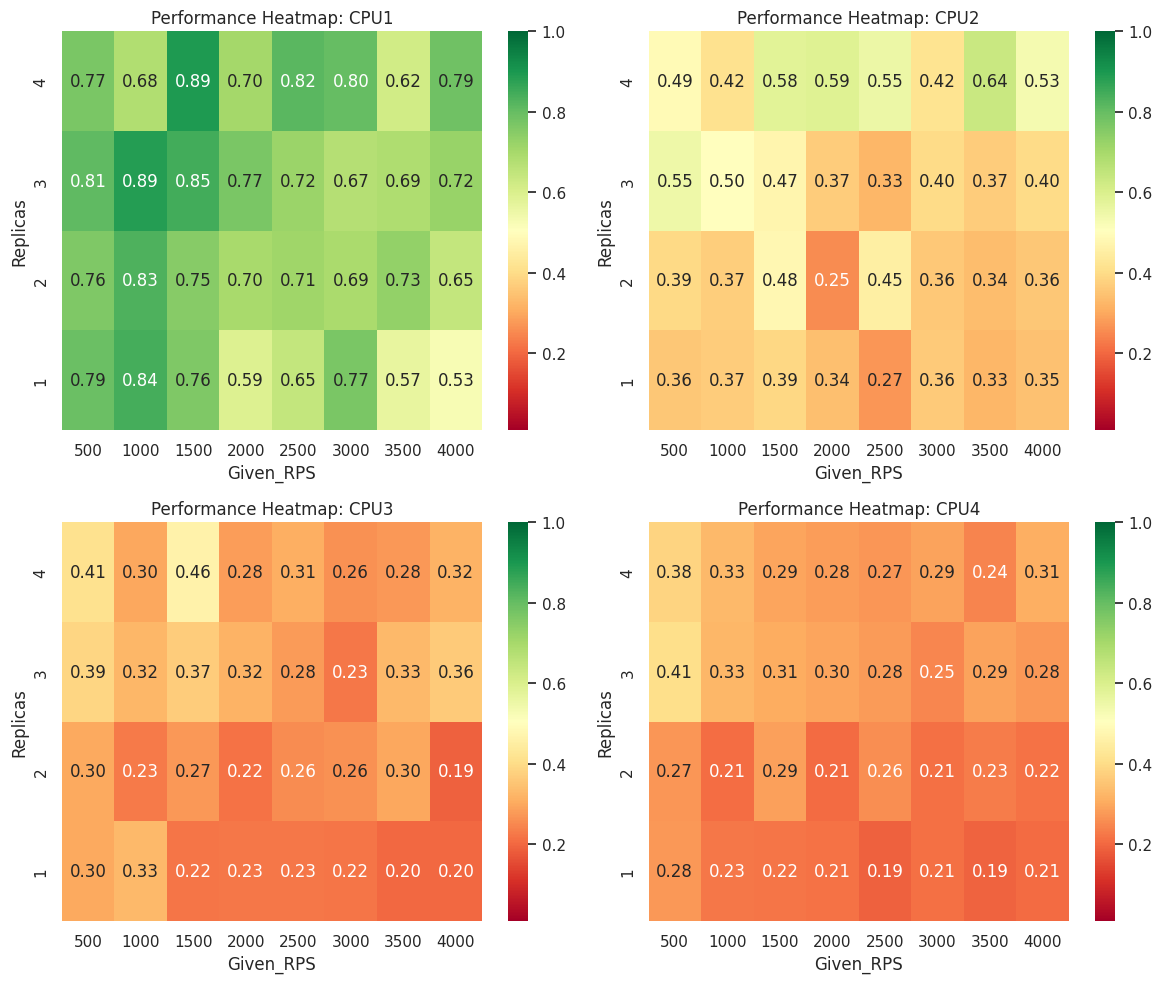

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter and set up the grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, scenario in enumerate(['CPU1', 'CPU2', 'CPU3', 'CPU4']):
    # Pivot the data to a matrix format required for heatmaps
    subset = summary_df[summary_df['Scenario_Label'] == scenario]
    pivot = subset.pivot(index='Replicas', columns='Given_RPS', values='Avg_Norm_Perf')
    
    # Plot using a 'Red-Yellow-Green' color map (vmax=1.0 as the ceiling)
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", ax=axes[i], vmin=0.01, vmax=1.0)
    axes[i].set_title(f'Performance Heatmap: {scenario}')
    axes[i].invert_yaxis() # Puts 4 replicas at the top

plt.tight_layout()
plt.show()

In [55]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import plotly.express as px

# 1. Prepare your data
# We'll use 'summary_df' from the previous step. 
# Make sure it only contains the CPU scenarios you want to compare.
plot_df = summary_df[summary_df['Scenario_Label'].str.contains('CPU')].copy()

# 2. Map categorical labels to numbers for the 3D engine
unique_labels = sorted(plot_df['Scenario_Label'].unique())
label_map = {label: i for i, label in enumerate(unique_labels)}
plot_df['Scenario_Idx'] = plot_df['Scenario_Label'].map(label_map)

line_styles = {1: 'solid', 2: 'dash', 3: 'dot', 4: 'dashdot'}
marker_symbols = {1: 'circle', 2: 'square', 3: 'diamond', 4: 'cross'}

# 3. Create the 3D Scatter Plot
# We use Scatter3d because it handles discrete 'Replica' groups well.
fig = go.Figure()

for replica in sorted(plot_df['Replicas'].unique()):
    rep_subset = plot_df[plot_df['Replicas'] == replica]
    
    # We iterate through scenarios so lines stay local to the label
    for label in unique_labels:
        scen_subset = rep_subset[rep_subset['Scenario_Label'] == label]
        
        # Only add a trace if there's data for this combo
        if not scen_subset.empty:

            text_labels = ["" for _ in range(len(scen_subset) - 1)]
            text_labels.append(f"{replica} Rep")

            fig.add_trace(go.Scatter3d(
                x=scen_subset['Scenario_Idx'],
                y=scen_subset['Given_RPS'],
                z=scen_subset['Avg_Norm_Perf'],
                mode='markers+lines',
                #text = text_labels,  # Add text labels for each point
                #textposition='top center',
                #legendgroup=f'rep_{replica}',
                showlegend=True if label == unique_labels[0] else False,
                name=f'{replica} Replicas',
                line=dict(
                    width=4, 
                    dash=line_styles.get(replica, 'solid'),
                    color=px.colors.qualitative.Plotly[replica % 10] # Consistent color
                ),
                marker=dict(
                    size=4, 
                    symbol=marker_symbols.get(replica, 'circle')
                )
            ))

# 4. Format the axes
fig.update_layout(
    #title=dict(text='CPU Performance Landscape', font=dict(size=30), x=0.5),
    width=1300,
    height=1000,
    scene=dict(
        xaxis=dict(
            title='Interference Scenario',
            tickvals=list(label_map.values()),
            ticktext=list(label_map.keys())
        ),
        yaxis=dict(title='Requests per second'),
        zaxis=dict(title='Normalized Performance', range=[0, 1.1]),
    ),
    margin=dict(l=0, r=0, b=0, t=0),
    legend=dict(
        orientation="h",      # Makes the legend horizontal as in image_396915.png
        yanchor="bottom",     # Anchors the legend at its bottom
        y=0.8,               # Places it just above the top of the graph (1.0 is the top edge)
        xanchor="center",     # Anchors the legend at its center
        x=0.5,                # Centers it horizontally
        title_text="Nginx Replicas"
    )
)

fig.show()

In [56]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

fig = go.Figure()

# Define the color scales for the different surfaces
colorscales = ['Reds', 'Greens', 'Purples', 'Oranges']

# Get unique RPS and Scenario values to build the grid
rps_vals = sorted(plot_df['Given_RPS'].unique())
scenario_idxs = sorted(plot_df['Scenario_Idx'].unique())
scenario_labels = sorted(plot_df['Scenario_Label'].unique())

for i, replica in enumerate(sorted(plot_df['Replicas'].unique())):
    # Filter for the specific replica
    rep_df = plot_df[plot_df['Replicas'] == replica]
    
    # Pivot the data to create a matrix of Avg_Norm_Perf
    # Rows = Scenario_Idx, Columns = Given_RPS
    pivot_df = rep_df.pivot(index='Scenario_Idx', columns='Given_RPS', values='Avg_Norm_Perf')
    
    # Ensure the grid is complete (reindex to fill any missing experiment holes with None)
    pivot_df = pivot_df.reindex(index=scenario_idxs, columns=rps_vals)
    
    fig.add_trace(go.Surface(
        z=pivot_df.values,
        x=pivot_df.columns,     # RPS
        y=pivot_df.index,       # Scenario Index
        name=f'{replica} Replicas',
        colorscale=colorscales[i % len(colorscales)],
        showscale=False,        # Hide individual colorbars to keep it clean
        opacity=0.8,
        legendgroup=f'rep_{replica}',
        showlegend=True
    ))

# Apply the horizontal legend and categorical axis labels
fig.update_layout(
    #title='3D Performance Landscape: Multi-Surface Analysis',
    width=1300,
    height=1000,
    scene=dict(
        xaxis=dict(title='Requests per second'),
        yaxis=dict(
            title='Interference Scenario',
            tickvals=scenario_idxs,
            ticktext=scenario_labels
        ),
        zaxis=dict(title='Normalized Performance', range=[0, 1])
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=0.8,
        xanchor="center",
        x=0.5,
        title_text="Nginx Replicas"
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()